In [4]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
from src.Propeller import Propeller
from src.JobParameters import AerodynamicParameters, AcousticParameters

with open("../10x5E.pkl", "rb") as f:
    blade_dict = pickle.load(f)

In [5]:
aerodynamic_params = AerodynamicParameters(
    prop_radius=blade_dict['tip_radius'],
    hub_radius=blade_dict['hub_radius'],
    n_blades=blade_dict['n_blades'],
    rpm=7000, v_inf=np.zeros(len(blade_dict['r'])), a_inf=343, rho=1.225, mu=1.81e-5
)

acoustic_params = AcousticParameters(
    aero_params=aerodynamic_params,
    p_ref=2e-5, revolutions=5, num_obs_times_per_rev=72
)

In [6]:
res = 50 
x_range = np.linspace(-5.0, 5.0, res)
y_range = np.linspace(-5.0, 5.0, res)
X, Y = np.meshgrid(x_range, y_range)
Z = np.zeros_like(X) 

r_observers = np.stack([X.flatten(), Y.flatten(), Z.flatten()], axis=1)

propeller = Propeller(
    propeller_geometry=blade_dict,
    aero_params=aerodynamic_params,
    acoustic_params=acoustic_params
)

propeller.run_bemt()
propeller.run_compact_f1a(observer_positions=r_observers)

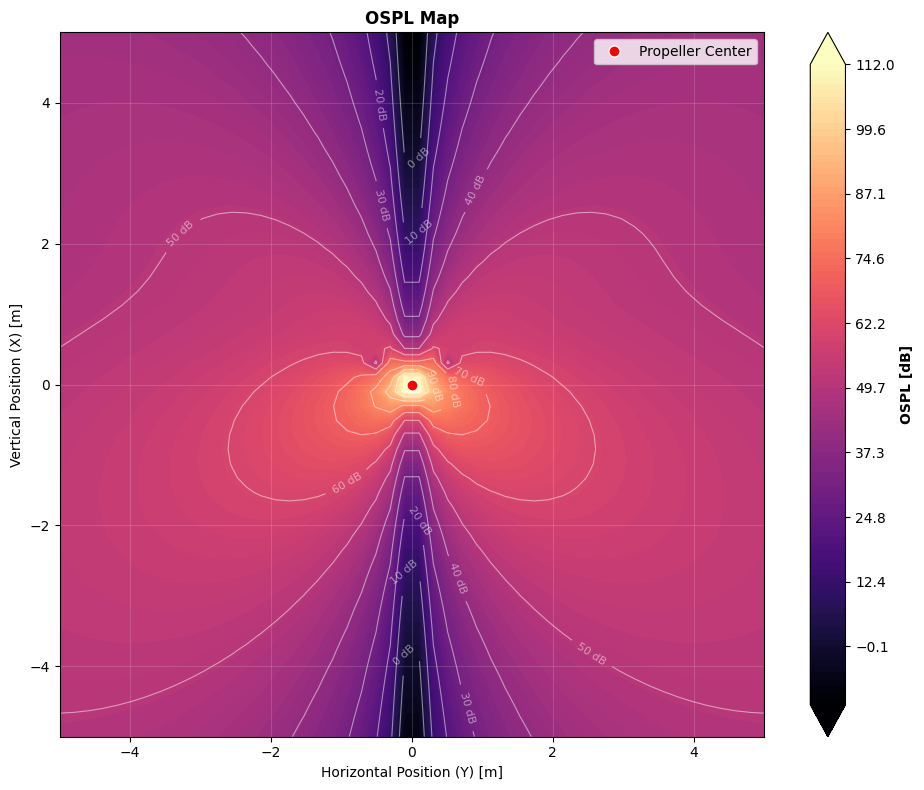

In [7]:
ospl_grid = propeller.ospl.reshape(X.shape)

fig, ax = plt.subplots(figsize=(10, 8))

smooth_levels = np.linspace(ospl_grid.min(), ospl_grid.max(), 100)
cf = ax.contourf(Y, X, ospl_grid, levels=smooth_levels, cmap='magma', extend='both')

cbar = fig.colorbar(cf, ax=ax)
cbar.set_label('OSPL [dB]', fontweight='bold')

line_levels = np.arange(0, np.max(ospl_grid) + 10, 10)
contours = ax.contour(Y, X, ospl_grid, levels=line_levels, colors='white', linewidths=0.8, alpha=0.5)
ax.clabel(contours, inline=True, fontsize=8, fmt='%1.0f dB')

ax.plot(0, 0, 'ro', markersize=8, label='Propeller Center', markeredgecolor='white')

ax.set_title('OSPL Map', fontweight='bold', fontsize=12)
ax.set_xlabel('Horizontal Position (Y) [m]', fontsize=10)
ax.set_ylabel('Vertical Position (X) [m]', fontsize=10)

ax.set_aspect('equal')
ax.grid(True, alpha=0.15, color='white')
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

In [8]:
from shapely.geometry import Polygon, box

target_level = 60.0
weight_below = 2.0  # Weight for the area where X < 0
weight_above = 1.0  # Weight for the area where X >= 0

specific_contour = ax.contour(Y, X, ospl_grid, levels=[target_level])
bottom_half_box = box(-5.0, -5.0, 5.0, 0.0) 
top_half_box = box(-5.0, 0.0, 5.0, 5.0)

area_above = 0.0
area_below = 0.0

for path in specific_contour.get_paths():
    vertices = path.vertices
    if len(vertices) > 3:
        poly = Polygon(vertices)
        
        poly_below = poly.intersection(bottom_half_box)
        poly_above = poly.intersection(top_half_box)
        
        area_below += poly_below.area
        area_above += poly_above.area

weighted_area = (area_below * weight_below) + (area_above * weight_above)
total_raw_area = area_below + area_above

print(f"--- Analysis for {target_level} dB ---")
print(f"Raw Area Below (X < 0): {area_below:.4f} m^2")
print(f"Raw Area Above (X >= 0): {area_above:.4f} m^2")
print(f"Weighted Total Area (Weight={weight_below}x): {weighted_area:.4f} m^2")

--- Analysis for 60.0 dB ---
Raw Area Below (X < 0): 6.6832 m^2
Raw Area Above (X >= 0): 1.4917 m^2
Weighted Total Area (Weight=2.0x): 14.8580 m^2
